In [1]:
import requests
import pandas as pd
pd.set_option('future.no_silent_downcasting', True)
import numpy as np
import json 
from pprint import pprint
import os.path
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
Dep = '77'

In [3]:
def get_dpe_data(url, params):
    """
    Récupère la première page de données DPE pour Paris (via le code postal 75*).
    """
    #print(f"Tentative de récupération des données DPE pour la commune {Dep}.")
    #print(f"Filtre de recherche (q) utilisé : {params['qs']}")

    #print(url)
    try:
        # Ajout d'un timeout pour éviter les blocages prolongés
        response = requests.get(url, params=params, timeout=30)
        response.raise_for_status()

        # Si la réponse est vide, on récupère un dict vide pour éviter les exceptions
        data = response.json() if response.content else {}
        lines = data.get('results', [])
        total_count = data.get('total', 'N/A')
        # Utiliser .get() pour éviter KeyError si 'next' est absent
        next_rows = data.get('next', None)

        # Débogage (décommenter si nécessaire)
        #print(f"\n Requête réussie.")
        #print(f"Nombre de résultats récupérés dans cette page : {len(lines)}")
        #print(f"Nombre total de résultats disponibles (estimation Data Fair) : {total_count}")
        #print(f"Next URL: {next_rows}")

        return lines, next_rows

    except ValueError as e:
        # Problème lors du décodage JSON
        print(f"Erreur lors du décodage JSON : {e}")
        return [], False

    except requests.exceptions.HTTPError as e:
        # Gère spécifiquement l'erreur 400 ou la fin de la requête forcée
        print(f"Erreur HTTP détectée : {e}")
        # Si c'est une erreur 400, on considère la pagination comme terminée
        if e.response.status_code == 400:
            print("Arrêt suite à l'erreur 400 (Bad Request).")
        return [], False # Retourne une liste vide et False pour l'échec/arrêt

    except requests.exceptions.RequestException as e:
        # Gère les erreurs de connexion, timeout, etc.
        print(f"Erreur lors de la requête HTTP : {e}")
        return [], False # Retourne une liste vide et False pour l'échec
    

In [ ]:
# URL de l'API ADEME Data Fair (DPE Logements existants depuis 2021)
URL_DPE = "https://data.ademe.fr/data-fair/api/v1/datasets/dpe03existant/lines"


#Nom du fichier qui contiendra les données nettoyées
fname=f'Dpe_dep_{Dep}.csv'

#Filtre : 
FILTRE = f'code_departement_ban:{Dep}'

#initialisation des parametres
PARAMETERS = {
        "q_mode":"simple",
        "size": 1000,
        "qs": FILTRE,
    }

In [4]:
existing=False
if os.path.isfile(fname):
    dpe_dep= pd.read_csv(fname)
    existing=True

else: 
    all_rows=[]
    
    next_url=URL_DPE
    
    while True :
        
        rows,next_url= get_dpe_data(next_url, PARAMETERS) #rows=les nouvelles lignes, next_url= la nouvelle url
        #print(next_url)
    
        if not next_url:
            # Arrêt si la fonction a rencontré une erreur HTTP (y compris 400)
            break
    
        if not rows:
            # Arrêt si la page est vide (fin naturelle des données)
            print("Aucune ligne trouvée. Fin.")
            break
        
        
        all_rows.extend(rows)
        if len(all_rows) % 100000 == 0:
            print(f"{len(all_rows)} lignes chargées...")
        PARAMETERS=None
        
    dpe_dep= pd.DataFrame(all_rows)
    

100000 lignes chargées...
200000 lignes chargées...


In [5]:
dpe_dep

,configuration_installation_chauffage_n1,conso_chauffage_installation_chauffage_n1,type_generateur_n1_ecs_n1,numero_voie_ban,score_ban,conso_auxiliaires_ep,deperditions_murs,cout_eclairage,conso_auxiliaires_ef,statut_geocodage,...,facteur_couverture_solaire_saisi_n1,type_generateur_n2_ecs_n1,volume_stockage_generateur_n2_ecs_n1,date_installation_generateur_n2_ecs_n1,usage_generateur_n2_ecs_n1,conso_ef_generateur_n2_ecs_n1,type_energie_generateur_n2_ecs_n1,facteur_couverture_solaire_saisi_installation_chauffage_n1,numero_rpls_logement,facteur_couverture_solaire_saisi_installation_chauffage_n2
0,Installation de chauffage simple,2741.9,CET sur air extérieur après 2014,312,0.56,675.9,28.2,43.1,355.7,adresse géocodée ban à l'adresse,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Installation de chauffage simple,8737.2,Ballon électrique à accumulation vertical Caté...,NaN,0.53,1224.3,59.6,41.9,644.3,adresse géocodée ban à l'adresse,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Installation de chauffage simple,5272.0,NaN,24,0.68,635.9,18.0,44.2,334.7,adresse géocodée ban à l'adresse,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Installation de chauffage simple,1201.9,Ballon électrique à accumulation horizontal,10,0.32,0.0,5.5,8.0,0.0,adresse géocodée ban à l'adresse,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Installation de chauffage simple,1291.3,Chaudière gaz standard 2001-2015,36,0.69,584.8,3.2,9.6,307.8,adresse géocodée ban à l'adresse,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
256995,Installation de chauffage simple,3929.2,PAC double service après 2014,16,0.64,774.2,6.0,43.7,336.6,adresse géocodée ban à l'adresse,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
256996,Installation de chauffage simple,4784.9,CET sur air ambiant (sur local non chauffé) ap...,35,0.97,302.1,25.5,21.0,131.3,adresse géocodée ban à l'adresse,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
256997,Installation de chauffage simple,6199.4,Chaudière gaz à condensation 2001-2015,41,0.59,1568.2,18.0,49.3,681.8,adresse géocodée ban à l'adresse,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
256998,Installation de chauffage simple,149533.0,Chaudière gaz à condensation après 2015,31,0.96,550.1,626.9,56.7,239.2,adresse non géocodée ban car aucune correspond...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Nettoyage des données

In [6]:
def profile_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """
    Analyse un DataFrame pour déterminer le type de données de chaque colonne,
    le nombre de valeurs manquantes (NaN) et le nombre de valeurs uniques.

    Args:
        df: Le DataFrame pandas à analyser.

    Returns:
        Un nouveau DataFrame contenant le profil de chaque colonne.
    """
    
    # Création d'un DataFrame vide pour stocker les résultats de l'analyse
    profile = pd.DataFrame(index=df.columns)
    
    # 1. Type des Variables (dtype)
    profile['Type de Variable'] = df.dtypes
    
    # 2. Nombre de Valeurs Manquantes (NaN)
    profile['Valeurs Manquantes (Count)'] = df.isnull().sum()
    
    # 3. Pourcentage de Valeurs Manquantes
    profile['Valeurs Manquantes (%)'] = (df.isnull().sum() / len(df)) * 100
    
    # 4. Nombre de Catégories Uniques (Cardinalité)
    profile['Nombre de Catégories Uniques'] = df.nunique()
    
    # 5. Type de Données Inférencé (Numérique, Catégorique, Date/Heure)
    def determine_data_class(series, max_unique_ratio=0.1):
        n_unique = series.nunique()
        n_rows = len(series)
        dtype = series.dtype

        # Si le type est déjà datetime
        if pd.api.types.is_datetime64_any_dtype(dtype):
            return 'Date/Heure'
        
        # Si c'est un type numérique
        if pd.api.types.is_numeric_dtype(dtype):
            # Si le nombre de valeurs uniques est inférieur à 10% de la taille, c'est probablement catégorique
            if n_unique / n_rows < max_unique_ratio and n_unique < 50:
                 return 'Numérique/Catégorique'
            return 'Numérique'
        
        # Pour les types objet (string)
        if dtype == 'object' or dtype == 'category':
            # Si peu de valeurs uniques par rapport au total, c'est catégorique
            if n_unique / n_rows < max_unique_ratio:
                return 'Catégorique'
            return 'Texte (ID/Nom)'
        
        return str(dtype) # Type par défaut

    profile['Classe Inférencée'] = df.apply(determine_data_class)
    
    return profile.sort_values(by='Nombre de Catégories Uniques', ascending=False)



In [7]:
# 2. Lancement de la fonction d'analyse
df_profil = profile_dataframe(dpe_dep)

# 3. Affichage du résultat
print("="*60)
print("Analyse de Profil du DataFrame :")
print("="*60)
print(df_profil)
print("\n")

Analyse de Profil du DataFrame :
                                                   Type de Variable  \
numero_dpe                                                   object   
_id                                                          object   
_i                                                            int64   
_rand                                                         int64   
conso_5_usages_ep                                           float64   
...                                                             ...   
volume_stockage_generateur_n2_ecs_n1                        float64   
type_energie_generateur_n2_ecs_n1                            object   
usage_generateur_n2_ecs_n1                                   object   
facteur_couverture_solaire_saisi_installation_c...          float64   
_score                                                       object   

                                                    Valeurs Manquantes (Count)  \
numero_dpe                      

C:\Users\lilym\AppData\Local\Temp\ipykernel_7360\1884368819.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


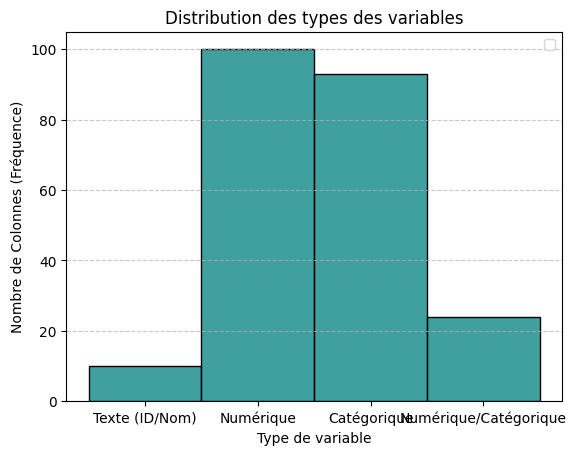

In [8]:
sns.histplot(df_profil['Classe Inférencée'], bins=20, color='teal')

plt.title('Distribution des types des variables')
plt.xlabel('Type de variable')
plt.ylabel('Nombre de Colonnes (Fréquence)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

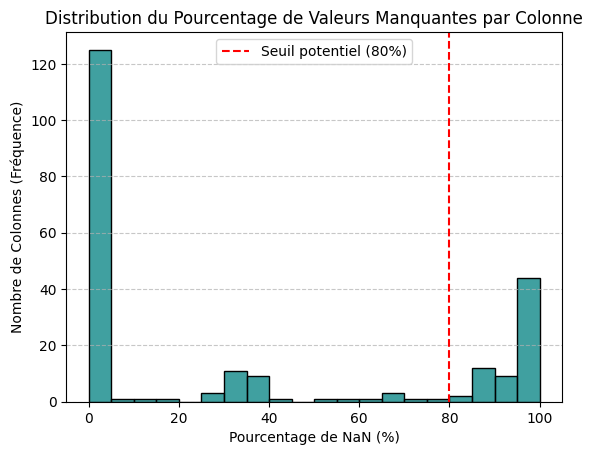

In [9]:
sns.histplot(df_profil['Valeurs Manquantes (%)'], bins=20,  color='teal')
SEUIL_VISUEL = 80
plt.axvline(SEUIL_VISUEL, color='red', linestyle='--', label=f'Seuil potentiel ({SEUIL_VISUEL}%)')

plt.title('Distribution du Pourcentage de Valeurs Manquantes par Colonne')
plt.xlabel('Pourcentage de NaN (%)')
plt.ylabel('Nombre de Colonnes (Fréquence)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

In [10]:
#Retirer les colonnes où il manque le plus de valeurs

lst=df_profil[df_profil['Valeurs Manquantes (%)']>78].index.values.tolist()
print(len(lst))

df_clean1=dpe_dep.copy().drop(columns=lst)

df_clean1

67


,configuration_installation_chauffage_n1,conso_chauffage_installation_chauffage_n1,type_generateur_n1_ecs_n1,numero_voie_ban,score_ban,conso_auxiliaires_ep,deperditions_murs,cout_eclairage,conso_auxiliaires_ef,statut_geocodage,...,emission_ges_ecs_energie_n2,emission_ges_chauffage_energie_n2,cout_chauffage_energie_n2,annee_construction,surface_ventilee,nombre_niveau_immeuble,type_ventilation,appartement_non_visite,numero_dpe_immeuble_associe,qualite_isolation_plancher_haut_toit_terrasse
0,Installation de chauffage simple,2741.9,CET sur air extérieur après 2014,312,0.56,675.9,28.2,43.1,355.7,adresse géocodée ban à l'adresse,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Installation de chauffage simple,8737.2,Ballon électrique à accumulation vertical Caté...,NaN,0.53,1224.3,59.6,41.9,644.3,adresse géocodée ban à l'adresse,...,138.6,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Installation de chauffage simple,5272.0,NaN,24,0.68,635.9,18.0,44.2,334.7,adresse géocodée ban à l'adresse,...,0.0,0.0,0.0,1970.0,NaN,NaN,NaN,NaN,NaN,NaN
3,Installation de chauffage simple,1201.9,Ballon électrique à accumulation horizontal,10,0.32,0.0,5.5,8.0,0.0,adresse géocodée ban à l'adresse,...,NaN,NaN,NaN,1995.0,21.0,1.0,VMC Basse pression Hygro A,0.0,NaN,NaN
4,Installation de chauffage simple,1291.3,Chaudière gaz standard 2001-2015,36,0.69,584.8,3.2,9.6,307.8,adresse géocodée ban à l'adresse,...,0.0,27.1,119.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
256995,Installation de chauffage simple,3929.2,PAC double service après 2014,16,0.64,774.2,6.0,43.7,336.6,adresse géocodée ban à l'adresse,...,136.9,0.0,0.0,NaN,66.6,NaN,VMC SF Hygro B après 2012,NaN,NaN,NaN
256996,Installation de chauffage simple,4784.9,CET sur air ambiant (sur local non chauffé) ap...,35,0.97,302.1,25.5,21.0,131.3,adresse géocodée ban à l'adresse,...,NaN,NaN,NaN,1960.0,51.7,NaN,VMC SF Hygro A après 2012,NaN,NaN,NaN
256997,Installation de chauffage simple,6199.4,Chaudière gaz à condensation 2001-2015,41,0.59,1568.2,18.0,49.3,681.8,adresse géocodée ban à l'adresse,...,0.0,0.0,0.0,2011.0,75.2,NaN,VMC SF Hygro A de 2001 à 2012,NaN,NaN,NaN
256998,Installation de chauffage simple,149533.0,Chaudière gaz à condensation après 2015,31,0.96,550.1,626.9,56.7,239.2,adresse non géocodée ban car aucune correspond...,...,0.0,0.0,0.0,1987.0,86.4,5.0,VMC SF Auto réglable de 1982 à 2000,0.0,2577E3857015W,NaN


In [11]:
#Supprimer les noms de colonnes à plus de 80% de valeurs manquantes dans df_profil

df_profil=df_profil.drop(lst)

df_profil


,Type de Variable,Valeurs Manquantes (Count),Valeurs Manquantes (%),Nombre de Catégories Uniques,Classe Inférencée
numero_dpe,object,0,0.000000,257000,Texte (ID/Nom)
_id,object,0,0.000000,257000,Texte (ID/Nom)
_i,int64,0,0.000000,257000,Numérique
_rand,int64,0,0.000000,226552,Numérique
conso_5_usages_ep,float64,13,0.005058,143652,Numérique
...,...,...,...,...,...
inertie_lourde,float64,99207,38.601946,2,Numérique/Catégorique
appartement_non_visite,float64,167919,65.338132,2,Numérique/Catégorique
modele_dpe,object,0,0.000000,1,Catégorique
code_region_ban,object,0,0.000000,1,Catégorique


C:\Users\lilym\AppData\Local\Temp\ipykernel_7360\2022057862.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


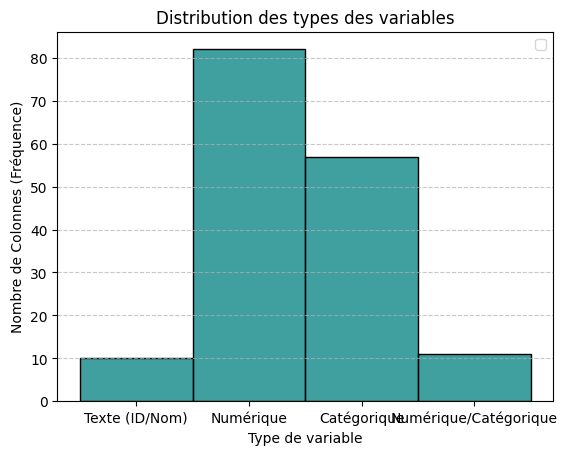

In [12]:
sns.histplot(df_profil['Classe Inférencée'], bins=30, color='teal')

plt.title('Distribution des types des variables')
plt.xlabel('Type de variable')
plt.ylabel('Nombre de Colonnes (Fréquence)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

In [13]:
def analyze_nan_by_row(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calcule le nombre et le pourcentage de NaN pour chaque ligne d'un DataFrame.

    Args:
        df: Le DataFrame pandas à analyser.

    Returns:
        Le DataFrame original avec deux nouvelles colonnes d'analyse.
    """
    

    # 1. Calcul du nombre de NaN par ligne
    df['nan_count_ligne'] = df.isnull().sum(axis=1)

    # 2. Calcul du pourcentage de NaN par ligne
    df['nan_pourcentage_ligne'] = (df['nan_count_ligne'] / (len(df.columns) - 1)) * 100

    return df

In [14]:
df_clean2=analyze_nan_by_row(df_clean1.copy())

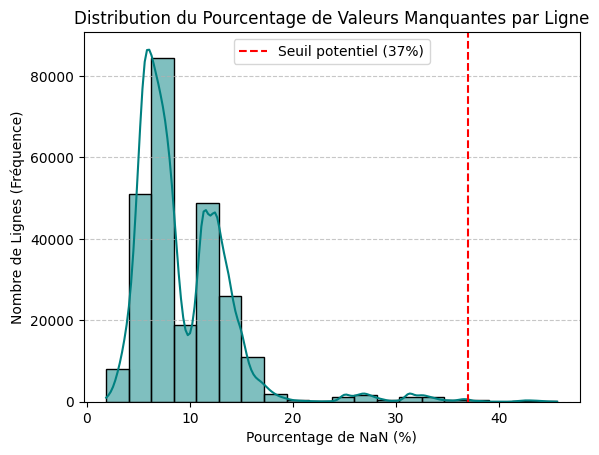

In [15]:
sns.histplot(df_clean2['nan_pourcentage_ligne'], bins=20, kde=True, color='teal')
SEUIL_VISUEL = 37
plt.axvline(SEUIL_VISUEL, color='red', linestyle='--', label=f'Seuil potentiel ({SEUIL_VISUEL}%)')

plt.title('Distribution du Pourcentage de Valeurs Manquantes par Ligne')
plt.xlabel('Pourcentage de NaN (%)')
plt.ylabel('Nombre de Lignes (Fréquence)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

In [16]:
def drop_rows_by_na_threshold(df: pd.DataFrame, threshold_percent) -> pd.DataFrame:
    """
    Supprime les lignes d'un DataFrame dont le pourcentage de valeurs 
    manquantes (NaN) est supérieur ou égal au seuil spécifié.

    Args:
        df: Le DataFrame pandas à nettoyer.
        threshold_percent: Le seuil de NaN à ne pas dépasser (en pourcentage, ex: 30 pour 30%).

    Returns:
        Un nouveau DataFrame nettoyé.
    """
    
    # 1. Calculer le nombre minimal de valeurs NON-MANQUANTES (valides)
    # Le seuil est appliqué au nombre de valeurs présentes, pas au nombre de NaN.
    
    # Calculer le ratio de valeurs NON-manquantes
    valid_ratio = 1 - (threshold_percent / 100)
    
    # Calculer le nombre minimum de valeurs non-NaN requises par ligne
    min_valid_count = int(np.floor(len(df.columns) * valid_ratio))
    
    # Si le seuil est 0, on garde tout le monde (sauf si on enlève les lignes vides)
    if threshold_percent == 100:
        min_valid_count = 1 # Garde toute ligne qui a au moins 1 valeur non-NaN

    print(f"Nombre total de colonnes : {len(df.columns)}")
    print(f"Seuil de NaN max autorisé : {threshold_percent}%")
    print(f"Nombre MINIMAL de valeurs valides requises par ligne : {min_valid_count}")
    
    # 2. Appliquer la suppression avec .dropna(thresh=...)
    # On crée une copie pour ne pas modifier le DataFrame original passé en argument
    df_cleaned = df.copy().dropna(axis=0, thresh=min_valid_count)
    
    lignes_supprimees = len(df) - len(df_cleaned)
    print(f"Lignes supprimées : {lignes_supprimees} (soit {lignes_supprimees/len(df)*100:.2f}%)")
    
    return df_cleaned

In [17]:
df_clean3 = drop_rows_by_na_threshold(df_clean2,37)

Nombre total de colonnes : 162
Seuil de NaN max autorisé : 37%
Nombre MINIMAL de valeurs valides requises par ligne : 102
Lignes supprimées : 459 (soit 0.18%)


In [18]:
def drop_nan_columns(df, threshold, use_percentage=True):
    """
    Supprime les colonnes ayant trop de valeurs manquantes (NaN).
    
    Args:
        df (pd.DataFrame): Ton DataFrame.
        threshold (float): Le seuil de tolérance. 
        use_percentage (bool): Si True, le seuil est un ratio (ex: 0.5 pour 50%).
                               Si False, le seuil est le nombre maximum de NaN autorisés.
    
    Returns:
        pd.DataFrame: Le DataFrame nettoyé.
    """
    if use_percentage:
        # On calcule le ratio de NaN par colonne
        nan_ratio = df.isna().mean()
        cols_to_drop = nan_ratio[nan_ratio > threshold].index
    else:
        # On compte le nombre brut de NaN
        nan_count = df.isna().sum()
        cols_to_drop = nan_count[nan_count > threshold].index
    
    print(f"Colonnes supprimées : {list(cols_to_drop)}")
    return df.drop(columns=cols_to_drop)

In [19]:
df_clean_final = drop_nan_columns(df_clean3.copy(),70)

Colonnes supprimées : []


# 1. Simplification du type de chauffage
def simplifier_chauffage(val):
    if pd.isna(val):
        return 'Autre/Inconnu'
    val = str(val).lower()
    if 'pac' in val or 'pompe' in val or 'thermodynamique' in val:
        return 'Pompe à Chaleur (PAC)'
    elif 'radiateur' in val or 'convecteur' in val or 'panneau' in val or 'rayonnant' in val or 'standard' in val:
        return 'Radiateur Électrique (Effet Joule)'
    elif 'chaudière' in val:
        return 'Chaudière Électrique'
    else:
        return 'Autre Élec'


if not df_clean_final.empty:
    # Filtrage pour l'électricité
    # Note: On vérifie si la colonne existe, car le nom peut varier légèrement selon les versions du CSV
    if 'type_energie_principale_chauffage' in df_clean_final.columns:
        df_elec = df_clean_final[df_clean_final['type_energie_principale_chauffage'] == 'Électricité'].copy()
    else:
        print("Attention : Colonne 'type_energie_principale_chauffage' introuvable. Utilisation du dataset complet (risqué).")
        df_elec = df_clean_final.copy()
        
    print(f"Nombre de logements sélectionnés (Chauffage Élec) : {df_elec.shape[0]}")

    # --- Création de features simplifiées ---


    if 'type_generateur_chauffage_principal' in df_elec.columns:
        df_elec['chauffage_simplifie'] = df_elec['type_generateur_chauffage_principal'].apply(simplifier_chauffage)
    else:
        df_elec['chauffage_simplifie'] = 'Inconnu'

    # 2. Logement Traversant
    if 'logement_traversant' in df_elec.columns:
        df_elec['logement_traversant_clean'] = df_elec['logement_traversant'].map({1.0: 'Oui', 0.0: 'Non'}).fillna('Inconnu')
    else:
         df_elec['logement_traversant_clean'] = 'Inconnu'

    # 3. Isolation Toiture
    if 'isolation_toiture' in df_elec.columns:
        df_elec['isolation_toiture_clean'] = df_elec['isolation_toiture'].map({1.0: 'Isolé', 0.0: 'Non Isolé'}).fillna('Inconnu')
    else:
        df_elec['isolation_toiture_clean'] = 'Inconnu'



In [20]:
# 1. Simplification du type de chauffage (Toutes énergies)
def simplifier_chauffage_global(val):
    if pd.isna(val):
        return 'Autre/Inconnu'
    
    val = str(val).lower()
    
    # Pompes à chaleur (PAC)
    if 'pac' in val or 'pompe' in val or 'thermodynamique' in val:
        return 'Pompe à Chaleur (PAC)'
        
    # Bois / Biomasse
    elif 'bois' in val or 'poêle' in val or 'insert' in val or 'granulé' in val or 'biomasse' in val:
        return 'Chauffage Bois/Biomasse'
        
    # Gaz
    elif 'gaz' in val:
        return 'Chaudière Gaz'
        
    # Fioul
    elif 'fioul' in val or 'fuel' in val:
        return 'Chaudière Fioul'
        
    # Électrique (Radiateurs classiques)
    elif 'radiateur' in val or 'convecteur' in val or 'panneau' in val or 'rayonnant' in val or 'effet joule' in val:
        return 'Radiateur Électrique'
        
    # Chaudière Électrique (spécifique)
    elif 'chaudière' in val and 'élec' in val:
        return 'Chaudière Électrique'
        
    # Réseaux de chaleur urbains
    elif 'réseau' in val or 'urbain' in val:
        return 'Réseau de Chaleur'
        
    # Chaudières génériques (si le type d'énergie n'est pas précisé dans le texte)
    elif 'chaudière' in val:
        return 'Chaudière (Autre)'
        
    else:
        return 'Autre'

# =========================================================

if not df_clean_final.empty:
    
    # On supprime le filtre "Électricité" pour garder tout le monde !
    df_processed = df_clean_final.copy()
        
    print(f"Nombre de logements sélectionnés (Tous chauffages) : {df_processed.shape[0]}")

    # --- Création de features simplifiées ---

    # 1. Chauffage
    if 'type_generateur_chauffage_principal' in df_processed.columns:
        df_processed['chauffage_simplifie'] = df_processed['type_generateur_chauffage_principal'].apply(simplifier_chauffage_global)
    else:
        df_processed['chauffage_simplifie'] = 'Inconnu'

    # 2. Logement Traversant
    if 'logement_traversant' in df_processed.columns:
        df_processed['logement_traversant_clean'] = df_processed['logement_traversant'].map({1.0: 'Oui', 0.0: 'Non'}).fillna('Inconnu')
    else:
         df_processed['logement_traversant_clean'] = 'Inconnu'

    # 3. Isolation Toiture
    if 'isolation_toiture' in df_processed.columns:
        df_processed['isolation_toiture_clean'] = df_processed['isolation_toiture'].map({1.0: 'Isolé', 0.0: 'Non Isolé'}).fillna('Inconnu')
    else:
        df_processed['isolation_toiture_clean'] = 'Inconnu'

Nombre de logements sélectionnés (Tous chauffages) : 256541


In [21]:
print(df_processed.columns.tolist())

['configuration_installation_chauffage_n1', 'conso_chauffage_installation_chauffage_n1', 'type_generateur_n1_ecs_n1', 'numero_voie_ban', 'score_ban', 'conso_auxiliaires_ep', 'deperditions_murs', 'cout_eclairage', 'conso_auxiliaires_ef', 'statut_geocodage', 'ventilation_posterieure_2012', 'cout_chauffage', 'conso_5_usages_par_m2_ep', 'date_etablissement_dpe', 'conso_ecs_ef_energie_n1', 'emission_ges_chauffage', 'description_installation_chauffage_n1', 'qualite_isolation_plancher_haut_comble_amenage', 'conso_5_usages_par_m2_ef', 'conso_chauffage_ef_energie_n1', 'presence_brasseur_air', 'qualite_isolation_menuiseries', 'date_reception_dpe', 'cout_total_5_usages_energie_n1', 'cout_ecs_energie_n1', 'qualite_isolation_plancher_bas', 'isolation_toiture', 'modele_dpe', 'qualite_isolation_enveloppe', 'conso_chauffage_generateur_n1_installation_n1', 'type_energie_n1', 'emission_ges_eclairage', 'code_postal_ban', 'emission_ges_ecs', 'conso_5_usages_ef', 'conso_5_usages_ef_energie_n1', 'code_insee

In [22]:
df_processed.to_csv(fname,index=False)
